# Planar Acoustic Pulse: Reflecting vs Non-Reflecting Boundaries

This example studies the effect of different boundary conditions on the reflection of an
acoustic pulse. A Gaussian pressure perturbation is initialised at the centre of a quasi-1D
domain and propagates to the right. Three right-boundary conditions are compared:


The left boundary uses `FarField` throughout (non-reflecting inflow). Top and bottom
boundaries are periodic, making the domain effectively one-dimensional.

**Reference:** Numerical setup follows Section IV.A of the CBC-HDG paper.

In [1]:
import numpy as np
import ngsolve as ngs
import matplotlib.pyplot as plt
from netgen.occ import OCCGeometry, WorkPlane
from netgen.meshing import IdentificationType
from dream.compressible_flow import (
    CompressibleFlowSolver, FarField, Outflow, GRCBC, Initial, flowfields
)

ngs.SetNumThreads(12)
ngs.ngsglobals.msg_level = 0

## Domain and Mesh

The domain is $\Omega = (-W/2, W/2) \times (-2h, 2h)$ with $W = 0.8$ and mesh size
$h = 0.07$. Top and bottom boundaries are identified periodically so the domain
behaves as a one-dimensional channel. The left boundary $\Gamma_{in}$ uses a non-reflecting
`FarField` condition throughout; the right boundary $\Gamma_{out}$ is varied between cases.

![Domain geometry](planar_acoustic_pulse_domain.png)

In [2]:
X    = 0.1        # pulse width
W    = 8 * X      # domain width  (-W/2 to W/2 in x)
maxh = 0.07       # mesh size

face = WorkPlane().RectangleC(W, 4 * maxh).Face()
face.name = 'inner'
face.maxh = maxh
for bc, edge in zip(['bottom', 'right', 'top', 'left'], face.edges):
    edge.name = bc
face.edges[0].Identify(face.edges[2], 'periodic', IdentificationType.PERIODIC)

mesh = ngs.Mesh(OCCGeometry(face, dim=2).GenerateMesh(maxh=maxh))

## Physical Setup

**Acoustic scaling** is used: $\rho_\infty = 1$, $c_\infty = 1$, $p_\infty = 1/\gamma$,
$|\mathbf{u}_\infty| = M_\infty = 0.03$. The initial condition is a rightward-propagating
acoustic pulse of strength $\alpha = 0.001$ centred at the origin:

$$
\rho_0 = \rho_\infty, \quad
p_0 = p_\infty\bigl(1 + \alpha\,e^{-x^2/X^2}\bigr), \quad
u_{x,0} = u_{\infty,x} + \frac{p_\infty}{\rho_\infty c_\infty}\,\alpha\,e^{-x^2/X^2}.
$$

The pulse travels rightward at $c_\infty + u_{\infty,x} \approx 1.03$ and reaches the right
boundary at $t \approx 0.39$. If the right BC reflects, the echo returns to the sensor
at $x = 0$ at $t \approx 0.80$.

In [3]:
cfg = CompressibleFlowSolver(mesh)
cfg.time                                  = 'transient'
cfg.time.timer.interval                   = (0.0, 1.5)
cfg.time.timer.step                       = 5e-3
cfg.mach_number                           = 0.03
cfg.scaling                               = 'acoustic'
cfg.dynamic_viscosity                     = 'inviscid'
cfg.equation_of_state                     = 'ideal'
cfg.equation_of_state.heat_capacity_ratio = 1.4
cfg.riemann_solver                        = 'lax_friedrich'
cfg.fem                                   = 'conservative_hdg'
cfg.fem.order                             = 4
cfg.fem.viscous_treatment                 = None
cfg.fem.bonus_int_order                   = 4
cfg.fem.scheme                            = 'bdf2'
cfg.fem.solver                            = 'direct'
cfg.fem.solver.method                     = 'newton'
cfg.fem.solver.method.damping_factor      = 1
cfg.fem.solver.method.max_iterations      = 5
cfg.fem.solver.method.convergence_criterion = 1e-8
cfg.io.log.to_terminal                    = False

Uinf  = cfg.get_farfield_fields((1, 0))

# Rightward-propagating acoustic pulse (acoustic scaling: c_inf = 1, p_inf = 1/gamma)
alpha = 0.001
gauss = ngs.exp(-ngs.x**2 / X**2)

U0 = flowfields()
U0.p   = Uinf.p * (1 + alpha * gauss)
U0.u   = Uinf.u + Uinf.p / (Uinf.rho * Uinf.c) * alpha * gauss * ngs.CF((1, 0))
U0.rho = Uinf.rho

## Simulation Loop

Each case uses the same left `FarField` (non-reflecting inflow) and swaps the
right boundary condition. The acoustic pressure
$p^* = (p - p_\infty)/(\alpha\,p_\infty)$ is sampled at the domain centre
$(x, y) = (0, 0)$ at every time step.

- At $t=0$: $p^* \approx 1$ — pulse is centred at the sensor.
- For $t \gtrsim 0.5$: $p^* \approx 0$ — pulse has left the sensor.
- Around $t \approx 0.8$: a second peak appears for reflecting BCs (echo returning to sensor).

In [4]:
cases = [
    ('FarField',       FarField(Uinf)),
    ('Outflow',        Outflow(Uinf.p)),
    ('GRCBC (C=0.01)', GRCBC(Uinf, target='farfield', relaxation_factor=0.01)),
]

results = {}

for label, right_bc in cases:
    print(f"Running {label}...")

    cfg.bcs.clear()
    cfg.dcs.clear()
    cfg.bcs['top|bottom'] = 'periodic'
    cfg.bcs['left']       = FarField(Uinf)
    cfg.bcs['right']      = right_bc
    cfg.dcs['inner']      = Initial(U0)

    cfg.initialize()

    Uh = cfg.get_solution_fields('p')
    times, p_sensor = [], []

    with ngs.TaskManager():
        for t in cfg.time.start_solution_routine():
            times.append(t)
            p_sensor.append(float(Uh.p(mesh(0.0, 0.0))))

    results[label] = (np.array(times), np.array(p_sensor))

print("Done.")

Running FarField...


Running Outflow...


Running GRCBC (C=0.01)...


Done.


## Results

The normalised acoustic pressure $p^*$ at the domain centre shows:
- `FarField` and `GRCBC`: the signal decays to zero and remains there — the pulse exits cleanly.
- `Outflow`: a reflected wave returns and is clearly visible around $t \approx 0.8$.

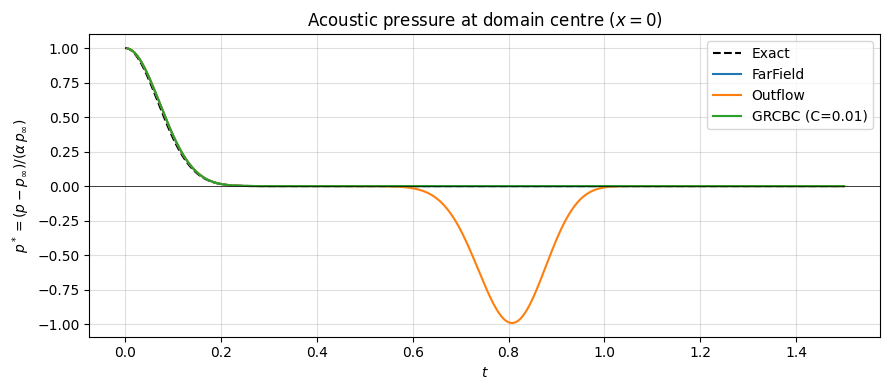

In [5]:
p_inf = 1.0 / 1.4  # acoustic scaling: p_inf = 1/gamma
M     = 0.03

fig, ax = plt.subplots(figsize=(9, 4))

# Exact solution: rightward Gaussian passing the sensor at x=0
t_plot = np.linspace(0.0, 1.5, 1000)
p_star_exact = np.exp(-((1 + M) * t_plot / X)**2)
ax.plot(t_plot, p_star_exact, 'k--', linewidth=1.5, label='Exact')

for label, (t, p) in results.items():
    p_star = (p - p_inf) / (alpha * p_inf)
    ax.plot(t, p_star, label=label)

ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$p^* = (p - p_\infty)/(\alpha\,p_\infty)$')
ax.set_title('Acoustic pressure at domain centre $(x=0)$')
ax.axhline(0, color='k', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()